In [1]:
from pymongo import MongoClient
from scipy import stats
from scipy.stats import chi2_contingency
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import joblib
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, recall_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore') 

In [2]:
client = MongoClient("mongodb://localhost:27017/")
collection = client["lendingclub_db"]["loans_clean"]
df = pd.DataFrame(list(collection.find()))

# Drop the MongoDB internal _id column
df = df.drop(columns=["_id"])
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,...,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
0,15850,15850,15850.0,36,16.24,559.12,C,C5,Counselor,1,...,0.0,559.12,0.0,64.0,1,INDIVIDUAL,0.0,0.0,53301.0,18400.0
1,7500,7500,7500.0,36,11.99,249.08,B,B3,Engineer,2,...,0.0,249.08,0.0,34.0,1,INDIVIDUAL,0.0,0.0,74029.0,10200.0
2,14125,14125,14100.0,36,16.99,503.53,D,D1,Customer Service Supervisor,8,...,0.0,503.53,0.0,46.0,1,INDIVIDUAL,0.0,0.0,20110.0,16100.0
3,16000,16000,16000.0,60,19.22,416.99,D,D4,District Sales Manager,8,...,0.0,416.99,0.0,60.0,1,INDIVIDUAL,0.0,0.0,188654.0,22600.0
4,10000,10000,10000.0,36,9.67,321.13,B,B1,driver,10,...,0.0,321.13,0.0,52.0,1,INDIVIDUAL,0.0,166.0,33685.0,15500.0


To Analyze:
1. Target variable distribution        ← bar chart, raw labels
2. Numeric distributions               ← histograms, log scale where needed
3. Correlation matrix heatmap          ← replaces all scatterplots
4. Grade/sub-grade vs default rate     ← heatmap
5. Employment length vs loan metrics   ← box plot
6. Grade and loan status               ← stacked bar (not pie)
7. Purpose vs loan status              ← stacked bar

In [3]:
df['loan_status'].value_counts()

loan_status
Current               8845
Late (31-120 days)     288
In Grace Period        131
Late (16-30 days)       66
Default                 37
Name: count, dtype: int64

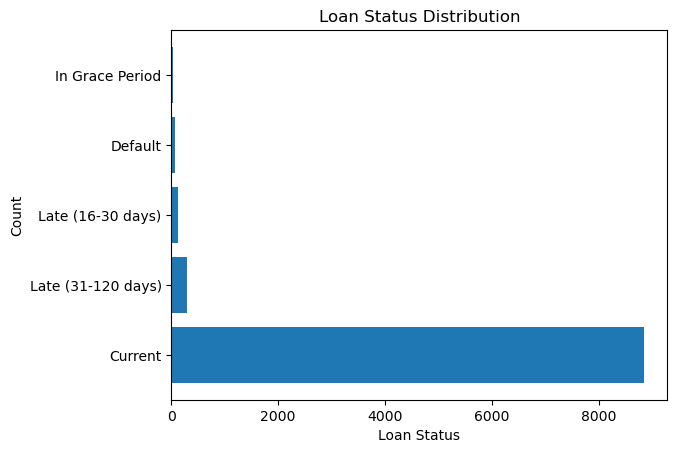

In [4]:
plt.barh(df['loan_status'].unique(), df['loan_status'].value_counts())
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

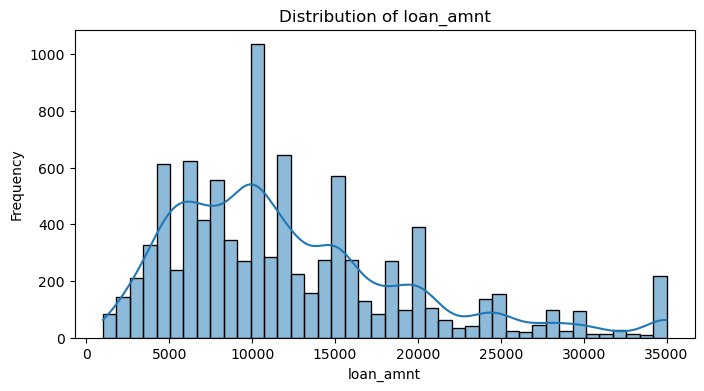

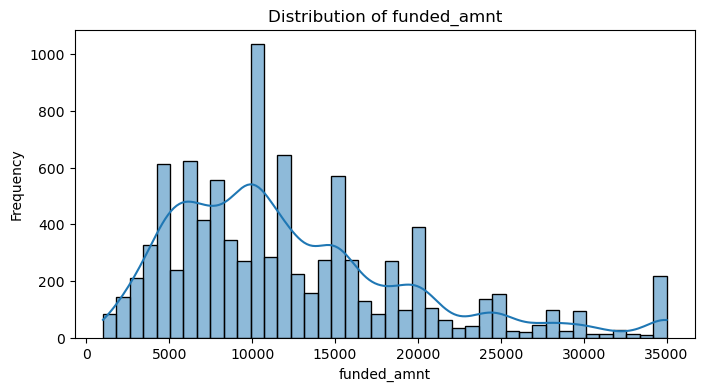

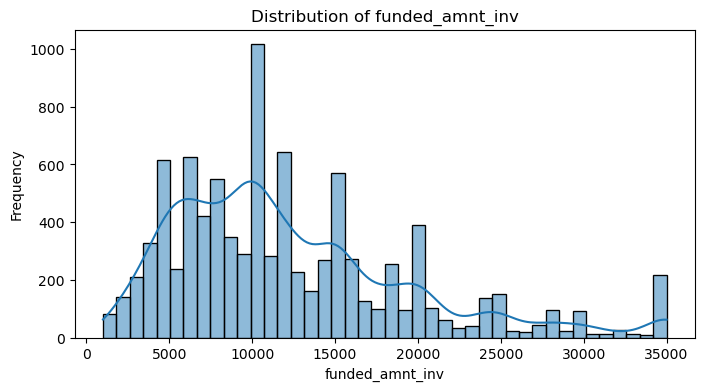

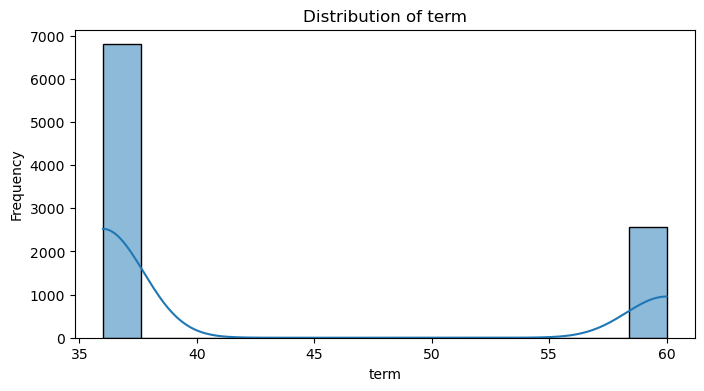

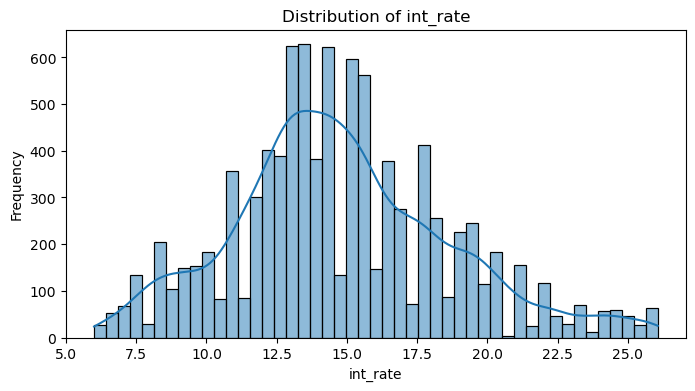

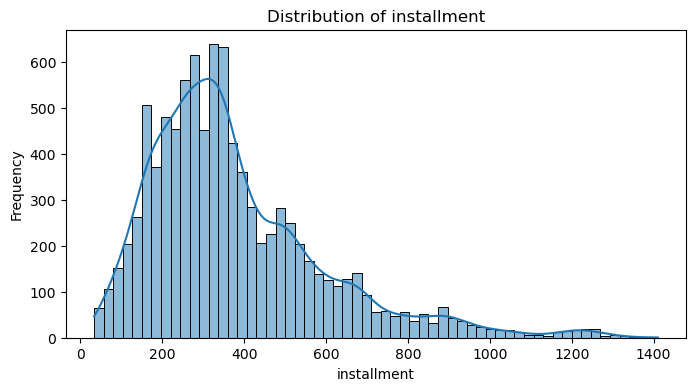

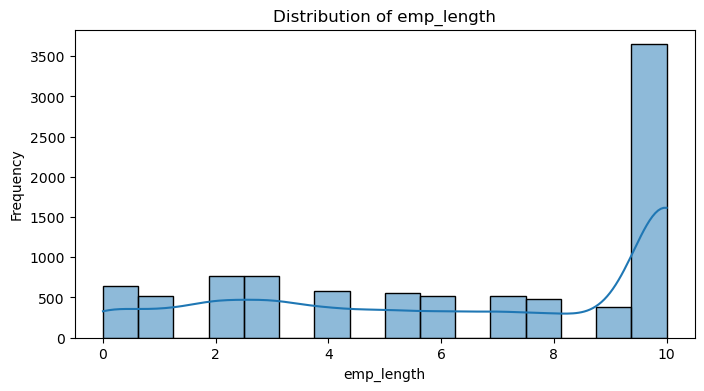

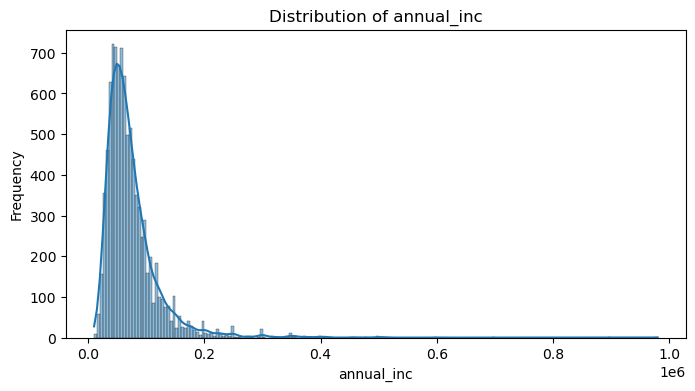

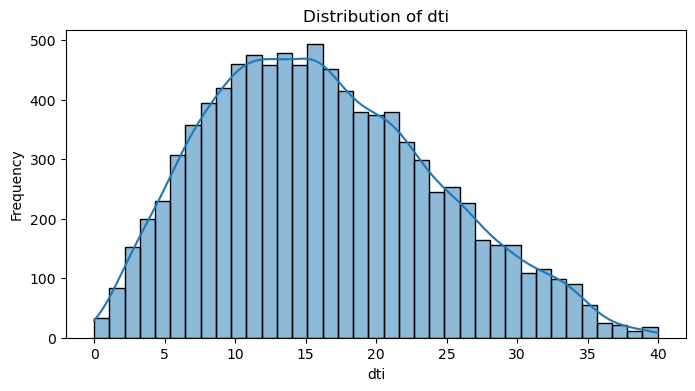

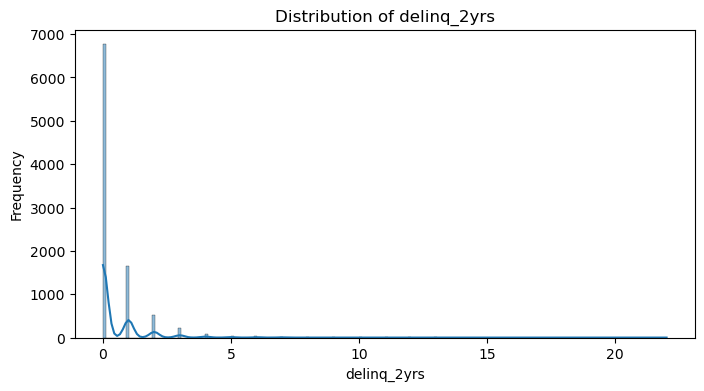

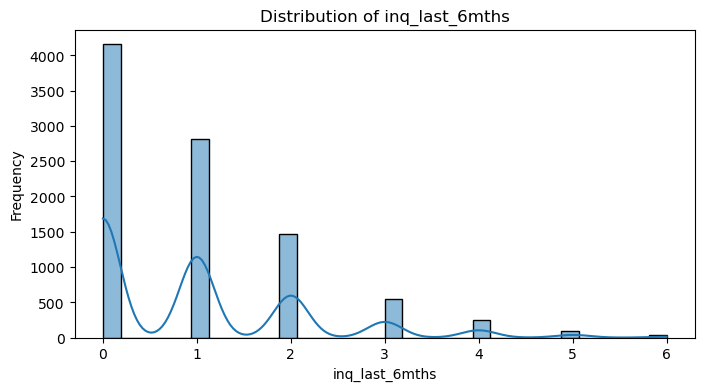

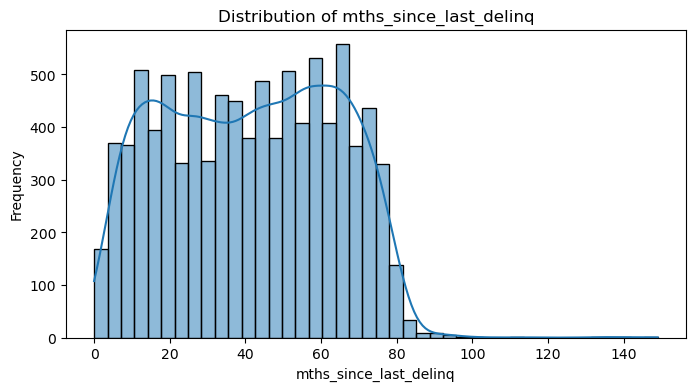

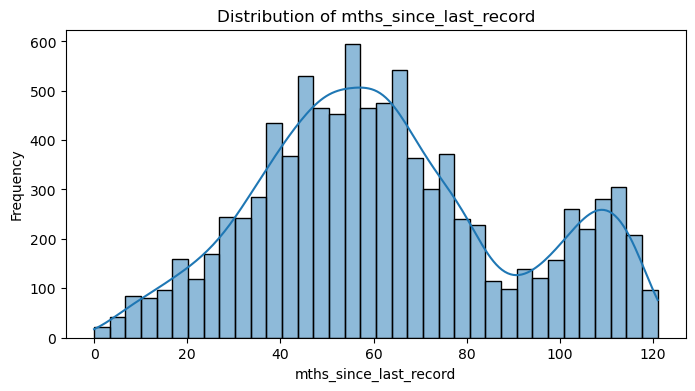

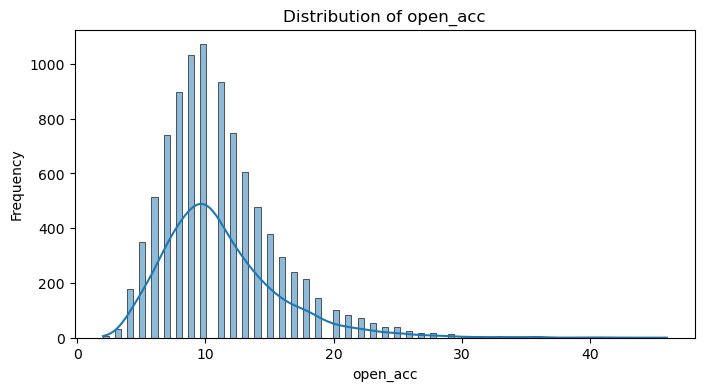

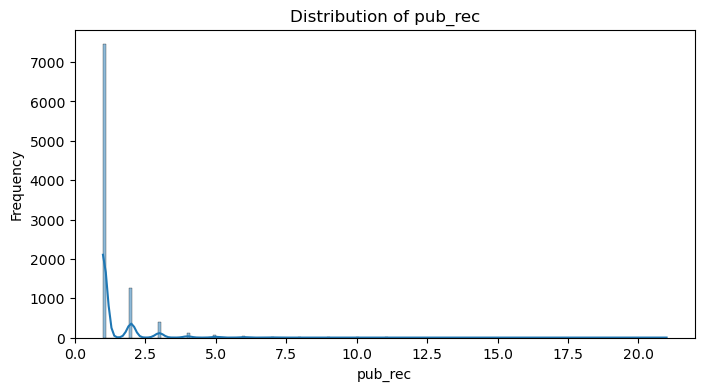

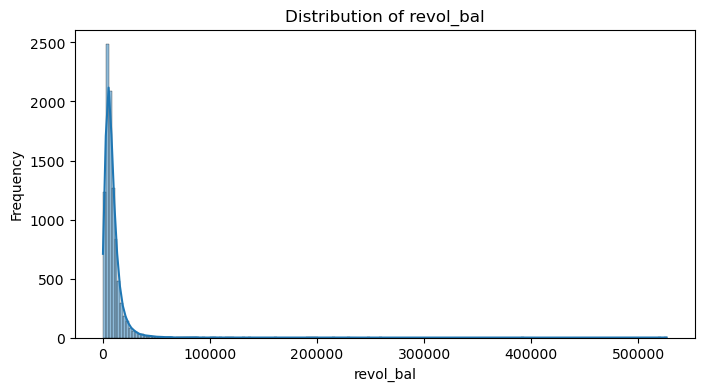

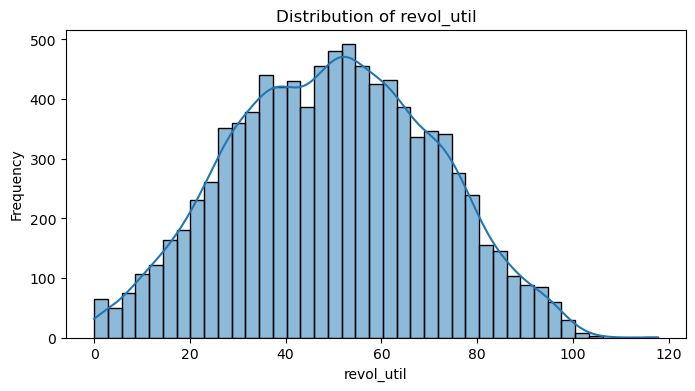

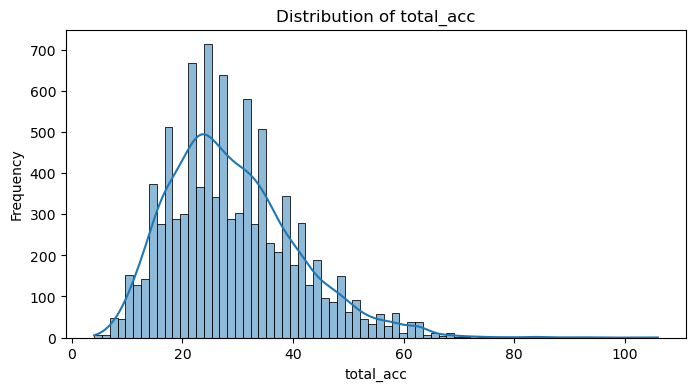

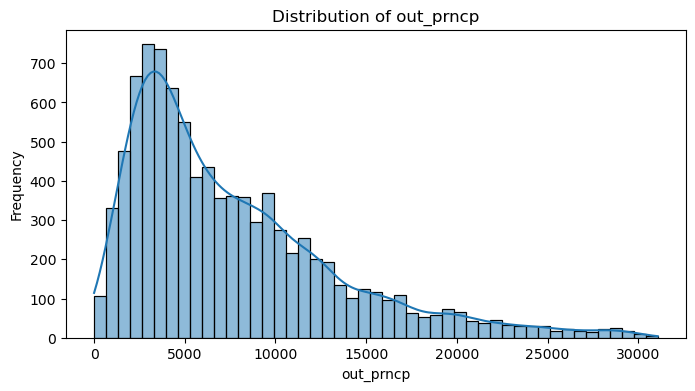

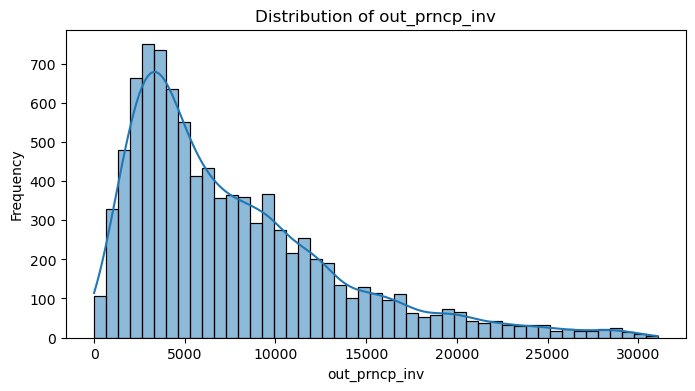

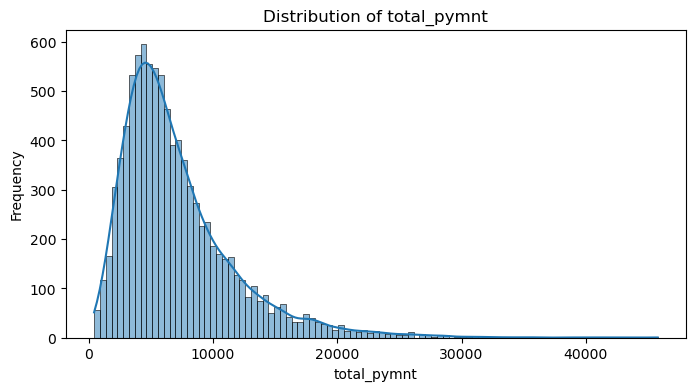

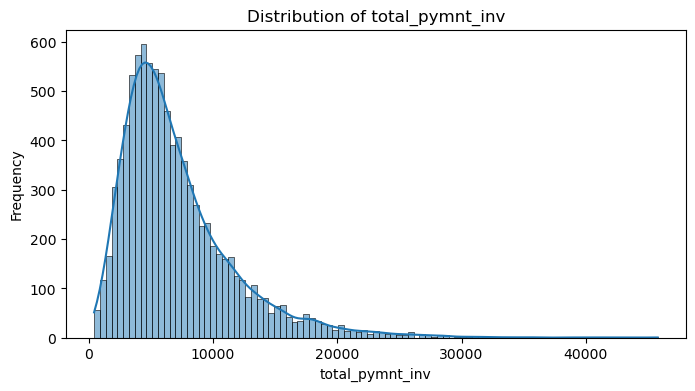

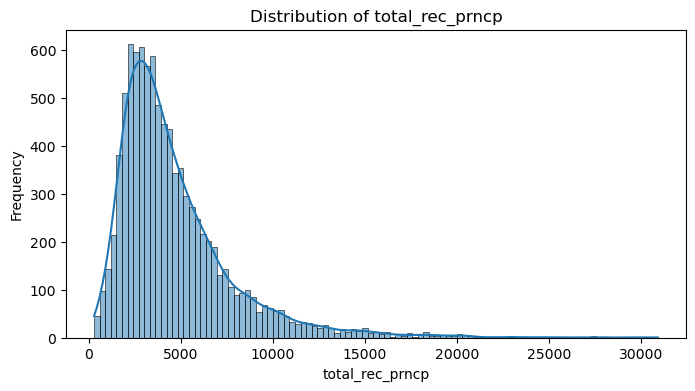

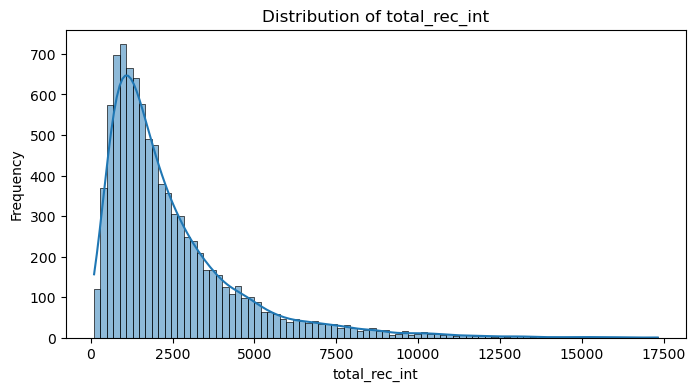

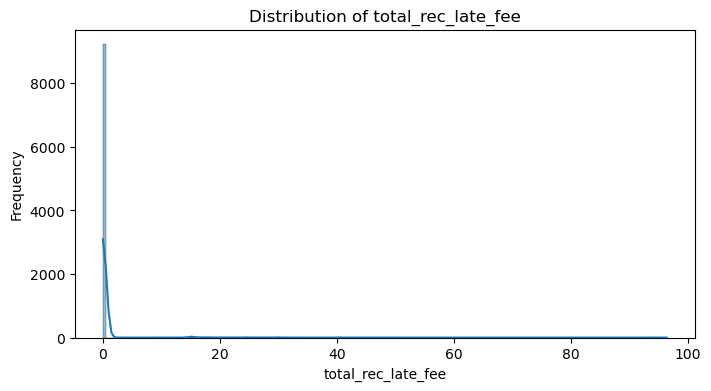

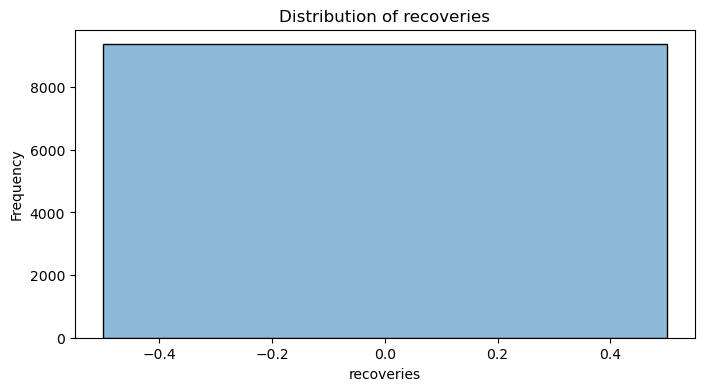

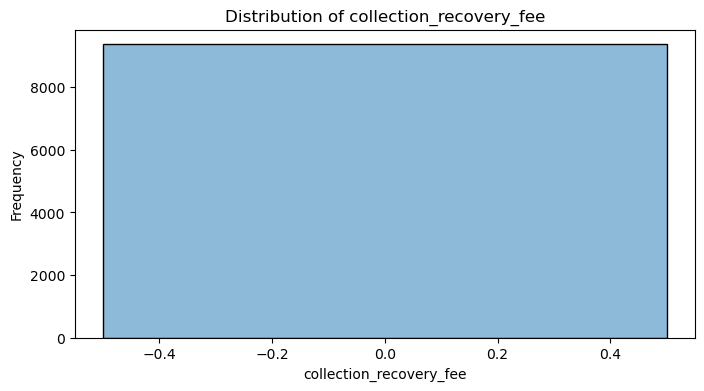

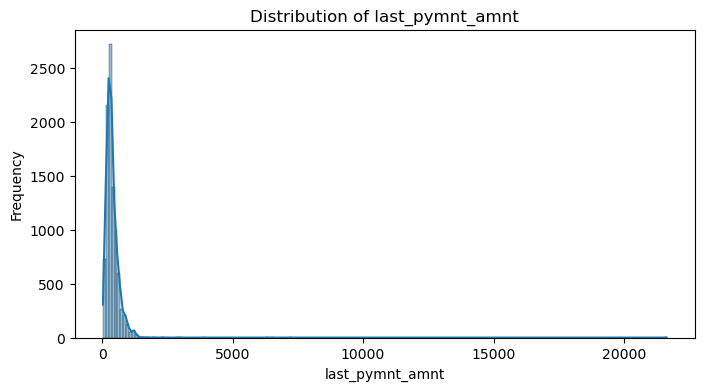

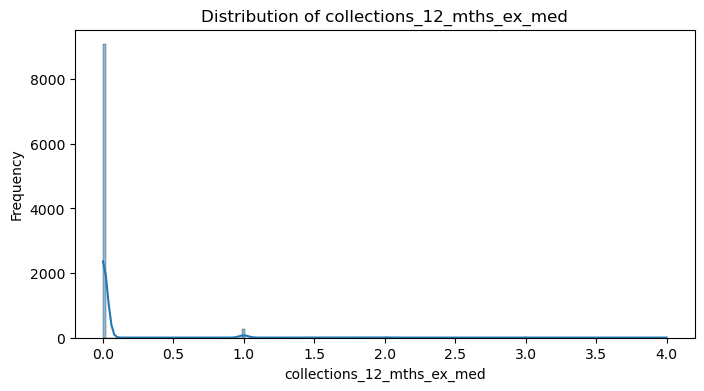

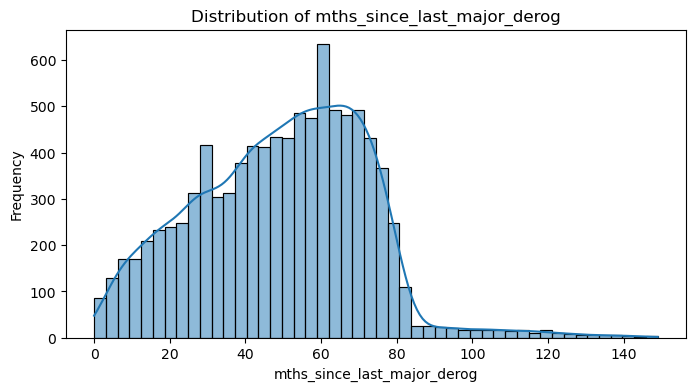

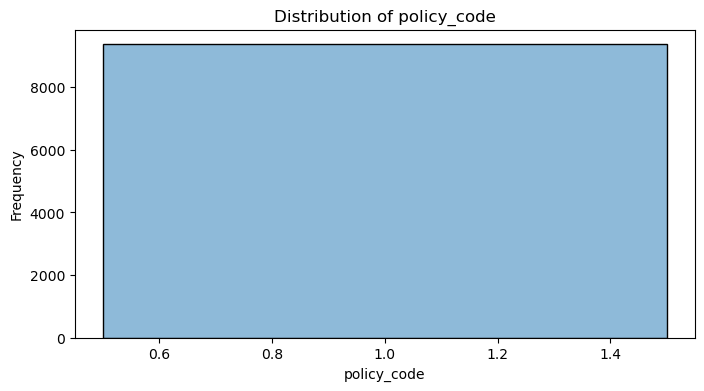

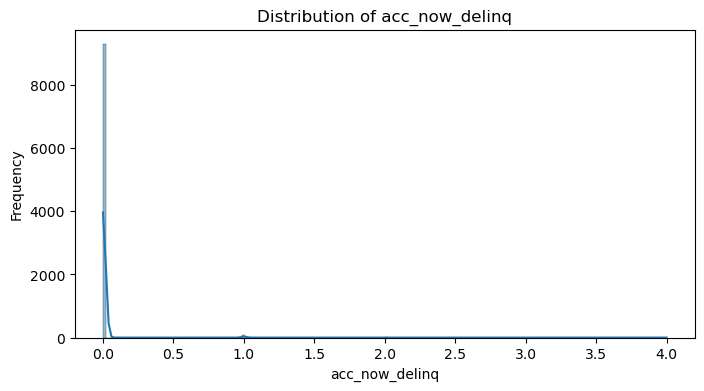

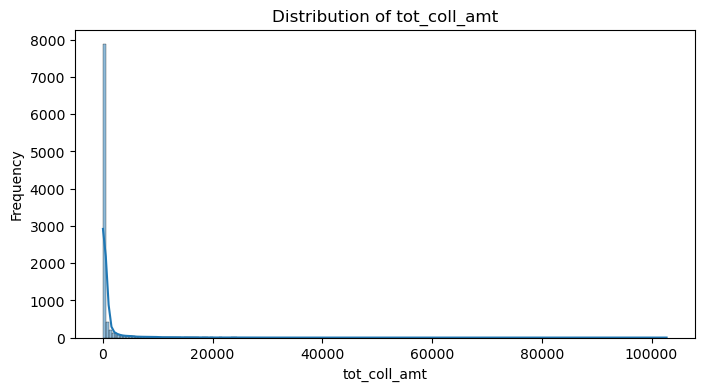

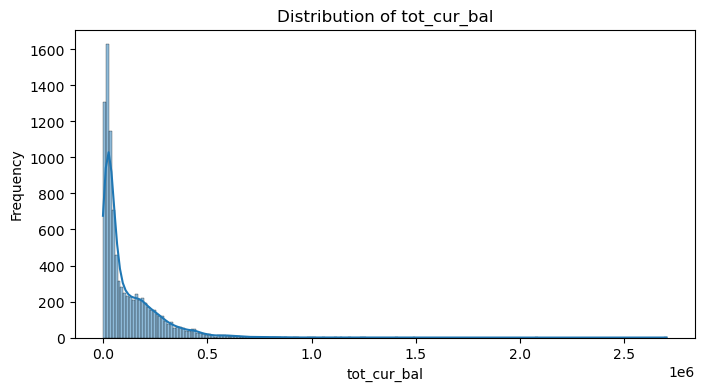

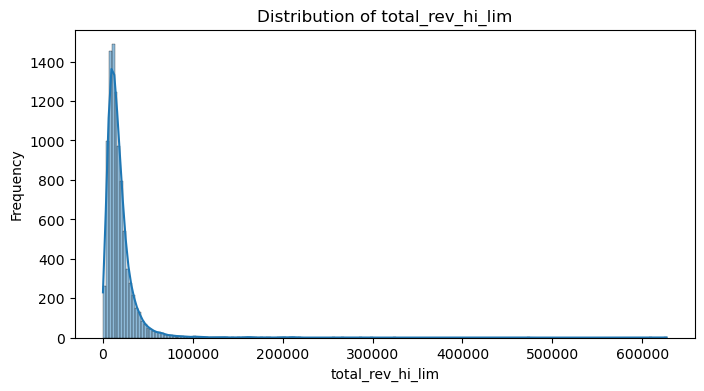

In [5]:
for col in df.columns:
    if df[col].dtype != 'object' and df[col].dtype != 'datetime64[ns]':
        plt.figure(figsize=(8, 4))
        sns.histplot(df[col], kde=True)
        plt.title(f'Distribution of {col}')
        plt.xlabel(col)
        plt.ylabel('Frequency')
        plt.show()

In [6]:
grade_a=df[df['grade']=='A']
grade_b=df[df['grade']=='B']
grade_c=df[df['grade']=='C']
grade_d=df[df['grade']=='D']
grade_e=df[df['grade']=='E']
grade_f=df[df['grade']=='F']
grade_g=df[df['grade']=='G']


In [7]:
df['loan_status'].unique()

array(['Current', 'Late (31-120 days)', 'Late (16-30 days)', 'Default',
       'In Grace Period'], dtype=object)